# Imports

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
import shap

# Load dataset (user should provide path to credit data)

In [5]:
try:
    df = pd.read_csv('credit_data.csv')
except Exception:
    # synthetic dataset
    n=2000
    df = pd.DataFrame({
    'age': np.random.randint(21,70,n),
    'income': np.random.normal(50000,15000,n).astype(int),
    'loan_amount': np.random.randint(1000,50000,n),
    'months_since_last_default': np.random.randint(0,60,n),
    'default': np.random.binomial(1,0.12,n)
    })


print(df.head())

   age  income  loan_amount  months_since_last_default  default
0   69   67582        27061                         56        0
1   50   39376        43584                         10        0
2   21   90478        31684                         41        0
3   51   50896        43266                         56        0
4   31   43508        21503                         21        0


# Basic preprocessing

In [8]:
# Basic preprocessing
X = df.drop(columns=['default'])
y = df['default']
X = pd.get_dummies(X, drop_first=True)


X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42)

# Baseline model

In [11]:
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train,y_train)


preds = rf.predict(X_test)
print(classification_report(y_test,preds))
print('ROC AUC:', roc_auc_score(y_test, rf.predict_proba(X_test)[:,1]))

              precision    recall  f1-score   support

           0       0.86      1.00      0.93       346
           1       0.00      0.00      0.00        54

    accuracy                           0.86       400
   macro avg       0.43      0.50      0.46       400
weighted avg       0.75      0.86      0.80       400

ROC AUC: 0.4740152001712696


C:\Users\Neliswa\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\Neliswa\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\Neliswa\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


# SHAP explanation


Saved SHAP summary plot as shap_summary.png


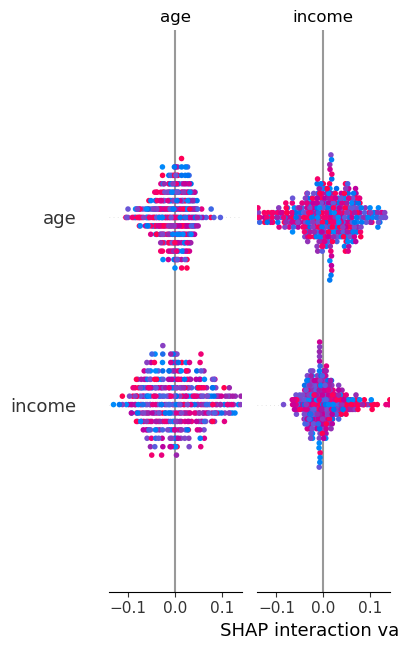

In [24]:
explainer = shap.TreeExplainer(rf)
shap_values = explainer.shap_values(X_test)
shap.summary_plot(shap_values, X_test, show=False)
plt.tight_layout()
plt.savefig('shap_summary.png')
print('\nSaved SHAP summary plot as shap_summary.png')